In [3]:
import numpy as np
import pygimli as pg
from pygimli.physics import ert

In [4]:
data3d = ert.load("slagdump3d.ohm")
print(data3d)

Data: Sensors: 577 data: 4245, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


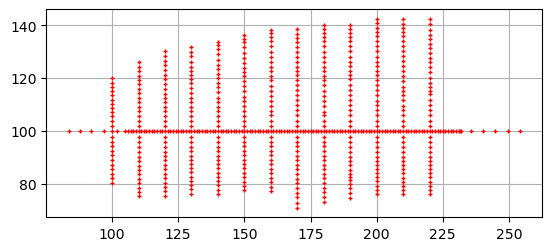

In [9]:
pg.plt.plot(pg.x(data3d), pg.y(data3d), 'r+');
pg.plt.gca().set_aspect(1.0)
pg.plt.grid();

In [13]:
def data3Dto2D(data):
    """Convert 3D ERT data to 2D by projecting onto a plane.

    Parameters
    ----------
    data : pg.DataContainerERT
        3D ERT data container.

    Returns
    -------
    pg.DataContainer
        2D data container.
    pos : ndarray
        interpolation 
    """
    # data2d = data.copy()
    xe = pg.x(data)
    ye = pg.y(data)
    ze = pg.z(data)
    xnew = np.hstack([0., np.cumsum(np.sqrt(np.diff(xe)**2 + np.diff(ye)**2))])
    txy = np.column_stack((xnew, xe, ye, ze))
    data.setSensors(np.column_stack((xnew, ze)))
    return data, txy

In [11]:
dataX150, txyX150 = data3Dto2D(data3d.subset(x=150))
print(dataX150)

Data: Sensors: 34 data: 173, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid', 'xa', 'xb', 'xm', 'xn']


In [12]:
dataX150.createGeometricFactors(numerical=True)
dataX150["rhoa"] = dataX150["r"] * dataX150["k"]
dataX150.ensure2D()

01/10/25 - 14:55:19 - pyGIMLi - INFO - Create default mesh for geometric factor calculation.
01/10/25 - 14:55:21 - pyGIMLi - INFO - Save RVector binary
01/10/25 - 14:55:21 - pyGIMLi - INFO - Cache stored: C:\Users\Thomas Guenther\AppData\Roaming\pygimli\Cache\18062828236322244075


In [14]:
dataX150.estimateError()
mgr = ert.Manager(dataX150)
mgr.invert(verbose=True)

01/10/25 - 14:55:38 - pyGIMLi - INFO - Found 2 regions.
01/10/25 - 14:55:38 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/10/25 - 14:55:38 - pyGIMLi - INFO - Found 2 regions.
01/10/25 - 14:55:38 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/10/25 - 14:55:38 - pyGIMLi - INFO - Creating forward mesh from region infos.
01/10/25 - 14:55:38 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
01/10/25 - 14:55:38 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1371 Cells: 2560 Boundaries: 2010
01/10/25 - 14:55:38 - pyGIMLi - INFO - Use median(data values)=12.494764213410708
01/10/25 - 14:55:38 - pyGIMLi - INFO - Created startmodel from forward operator:501, min/max=12.494764/12.494764
01/10/25 - 14:55:38 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001E7BEAC31F0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 6.32/66.08
min/max (error): 3%/3%
min/max (start model): 12.49/12.49
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  356.08
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   27.53 (dPhi = 90.67%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    2.52 (dPhi = 71.75%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.15 (dPhi = 1.64%) lam: 20.0
################################################################################
#                Abort criterion reached: dPhi = 1.64 (< 2.0%)                 #
##########################

501 [141.23377853938646,...,6.410647367734284]

In [ ]:
def model2Dto3D(mesh, txy):
    """Convert 2D model to 3D by interpolation.

    Parameters
    ----------
    model2d : pg.Vector
        2D model vector.
    txy : ndarray
        interpolation table.

    Returns
    -------
    pg.Vector
        3D model vector.
    """
    mt = pg.x(mesh)
    mz = pg.y(mesh)
    mx = np.interp(mt, txy[:, 0], txy[:, 1])
    my = np.interp(mt, txy[:, 0], txy[:, 2])
    mesh.setDimension(3)
    for i, node in enumerate(mesh.nodes()):
        node.setPos([mx[i], my[i], mz[i]])

In [18]:
outX150 = mgr.paraDomain
outX150["res"] = mgr.paraModel()
mt = pg.x(outX150)
mz = pg.y(outX150)
mx = np.interp(mt, txyX150[:, 0], txyX150[:, 1])
my = np.interp(mt, txyX150[:, 0], txyX150[:, 2])
outX150.setDimension(3)
for i, node in enumerate(outX150.nodes()):
    node.setPos([mx[i], my[i], mz[i]])

pg.show(outX150, "res")

Widget(value='<iframe src="http://localhost:53703/index.html?ui=P_0x1e7be9fbd50_0&reconnect=auto" class="pyvis…

(<pyvista.plotting.plotter.Plotter at 0x1e7be9fbd50>, None)

In [41]:
datay = data3d.subset(y=100)
datay.setSensors(np.column_stack((pg.x(datay), pg.z(datay))))
datay.createGeometricFactors(numerical=True)
datay["rhoa"] = datay["r"] * datay["k"]
datay.ensure2D()
datay.estimateError()
mgr = ert.Manager(datay)
mgr.invert(verbose=True)

30/09/25 - 19:37:16 - pyGIMLi - INFO - Cache c:\src\gimli\gimli\pygimli\physics\ert\ert.py:createGeometricFactors restored (12.7s x 1): C:\Users\Thomas Guenther\AppData\Roaming\pygimli\Cache\9434851310527507784
30/09/25 - 19:37:16 - pyGIMLi - INFO - Found 2 regions.
30/09/25 - 19:37:16 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
30/09/25 - 19:37:17 - pyGIMLi - INFO - Found 2 regions.
30/09/25 - 19:37:17 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
30/09/25 - 19:37:17 - pyGIMLi - INFO - Creating forward mesh from region infos.
30/09/25 - 19:37:17 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
30/09/25 - 19:37:17 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 5119 Cells: 9608 Boundaries: 7520
30/09/25 - 19:37:17 - pyGIMLi - INFO - Use median(data values)=13.032770039976105
30/09/25 - 19:37:17 - pyGIMLi - INFO - Created startmodel from forward operator:2188, min/max=13.032770/13.032770
30/09/25 - 

fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000029A95E70720>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 6.66/211
min/max (error): 3%/3%
min/max (start model): 13.03/13.03
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  484.16
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   39.62 (dPhi = 91.24%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   10.26 (dPhi = 70.97%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    9.81 (dPhi = 2.53%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    9.79 (dPhi = 0.47%) lam: 20.0
######################################################

2188 [110.38623034577267,...,16.22838186990233]

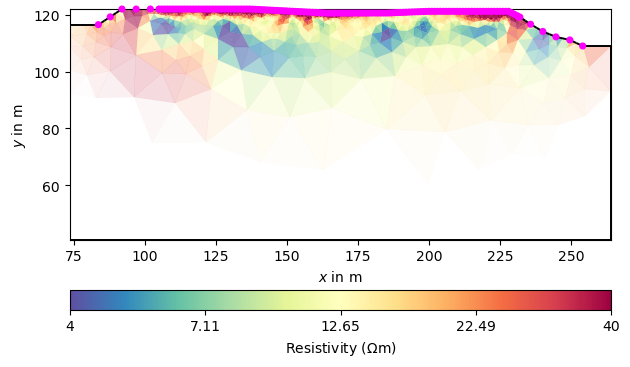

In [33]:
mgr.showResult(cMin=4, cMax=40);

In [42]:
out2 = mgr.paraDomain
out2["res"] = mgr.paraModel()
out2.setDimension(3)
for node in out2.nodes():
    node.setPos([node.pos().x(), 100, node.pos().y()])
pg.show(out2, "res")

Widget(value='<iframe src="http://localhost:59685/index.html?ui=P_0x29a95ee2950_2&reconnect=auto" class="pyvis…

(<pyvista.plotting.plotter.Plotter at 0x29a95ee2950>, None)

In [47]:
kw = dict(cMin=4, cMax=40, logScale=True, cMap="Spectral_r")
pl, _ = pg.show(out, "res", hold=True, **kw)
pg.show(out2, "res", ax=pl, **kw)

Widget(value='<iframe src="http://localhost:59685/index.html?ui=P_0x29abb341e10_7&reconnect=auto" class="pyvis…

(<pyvista.plotting.plotter.Plotter at 0x29abb341e10>, None)